# Solar v6 — Visual Analysis
Run the v6 training notebook first. All plots here assume the models and predictions are already in memory.

c:\ProgramData\anaconda3\envs\ai_stack\lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


Rows: 262,964  |  2022-01-08 → 2026-04-12
Feature engineering done.
  Synthetic rows: 81,627 (excluded from kt training)
kt estimator features   : 13
Sensor model features   : 19
Oracle-free features    : 19

FEATURES_SENSOR and FEATURES_ORACLE are structurally identical.
Only the solar columns differ: actual vs kt-estimated versions.
Rows after clean: 262,964
Train: 183,365  2022-01-08 → 2024-12-27
Test : 79,599  2024-12-28 → 2026-04-12
Monsoon kt: train R²=0.5498  test R²=0.4252
Dry kt:     train R²=0.5105  test R²=0.2305
Training set kt_est R² (full models applied to train): 0.4356
Test set     kt_est R² (full models applied to test):  0.2686

Note: training R² is higher because the kt models were fit on this data.
Test R² is the honest out-of-sample estimate of kt prediction quality.
This gap is expected and acceptable — it is accounted for by training the
oracle-free power model on the same estimated features.
  Fold 1: sensor R²=0.8591   oracle-free R²=0.3545
  Fold 2: sensor R²=

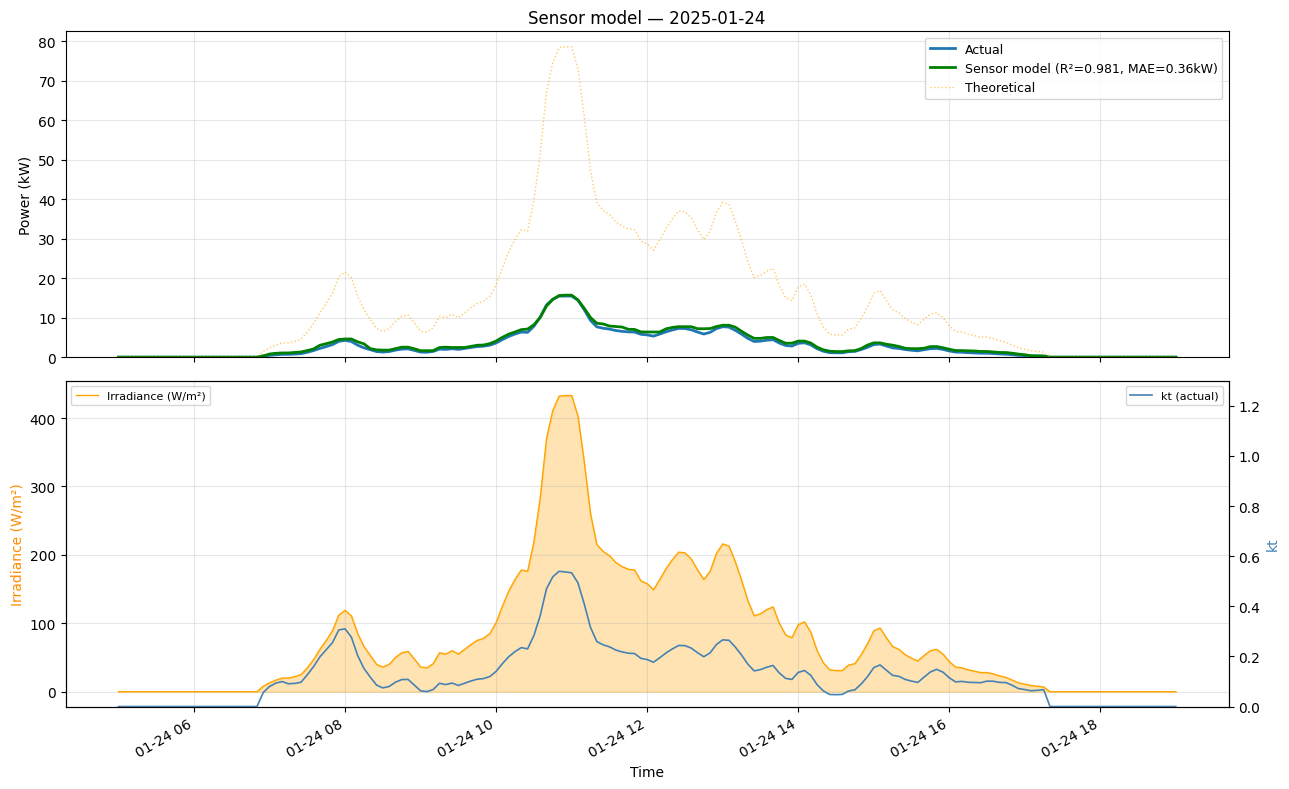

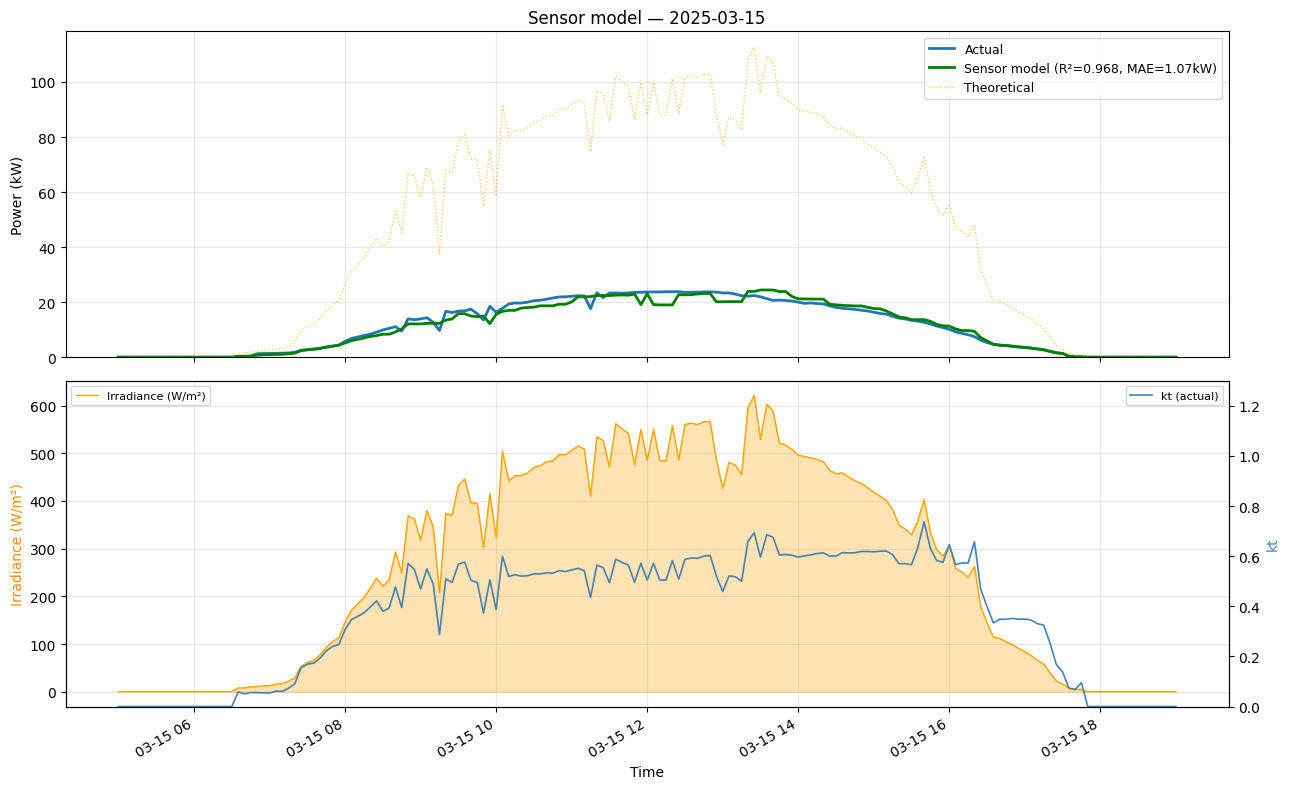

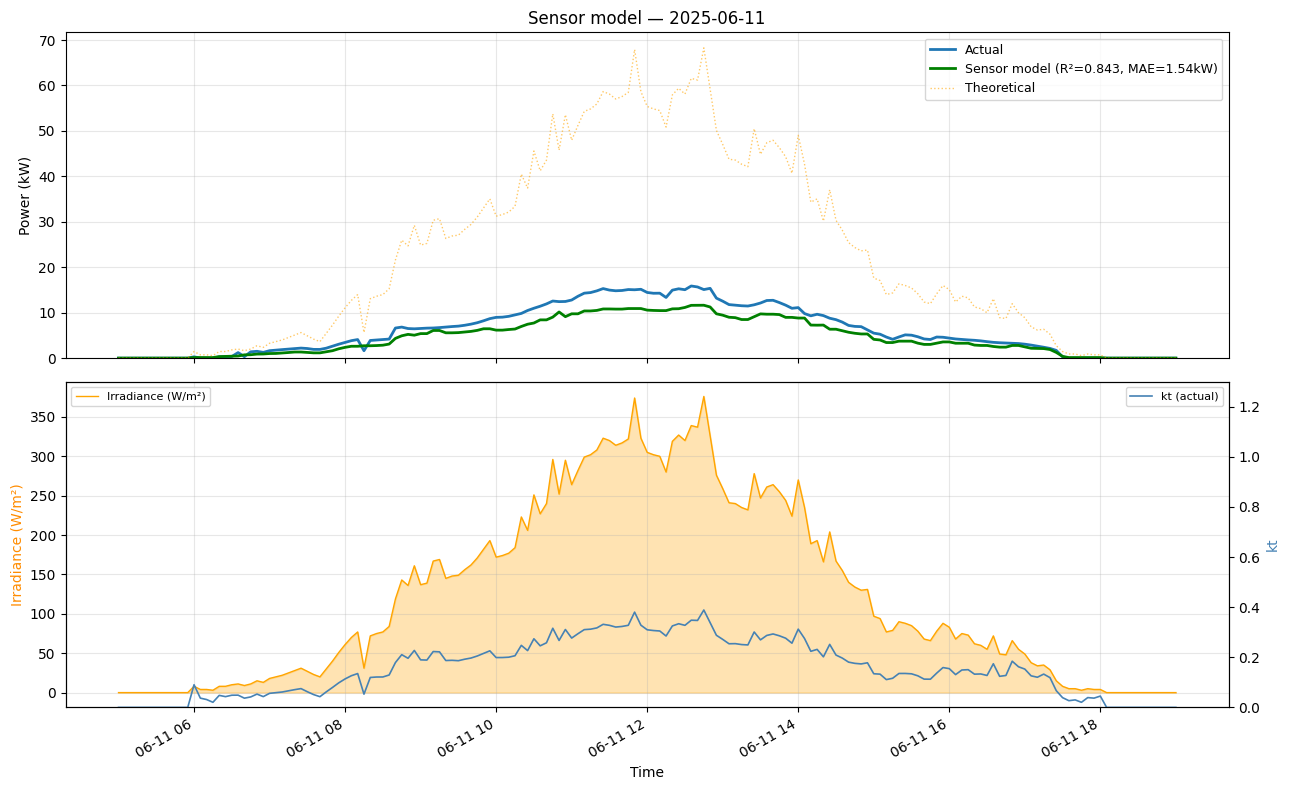

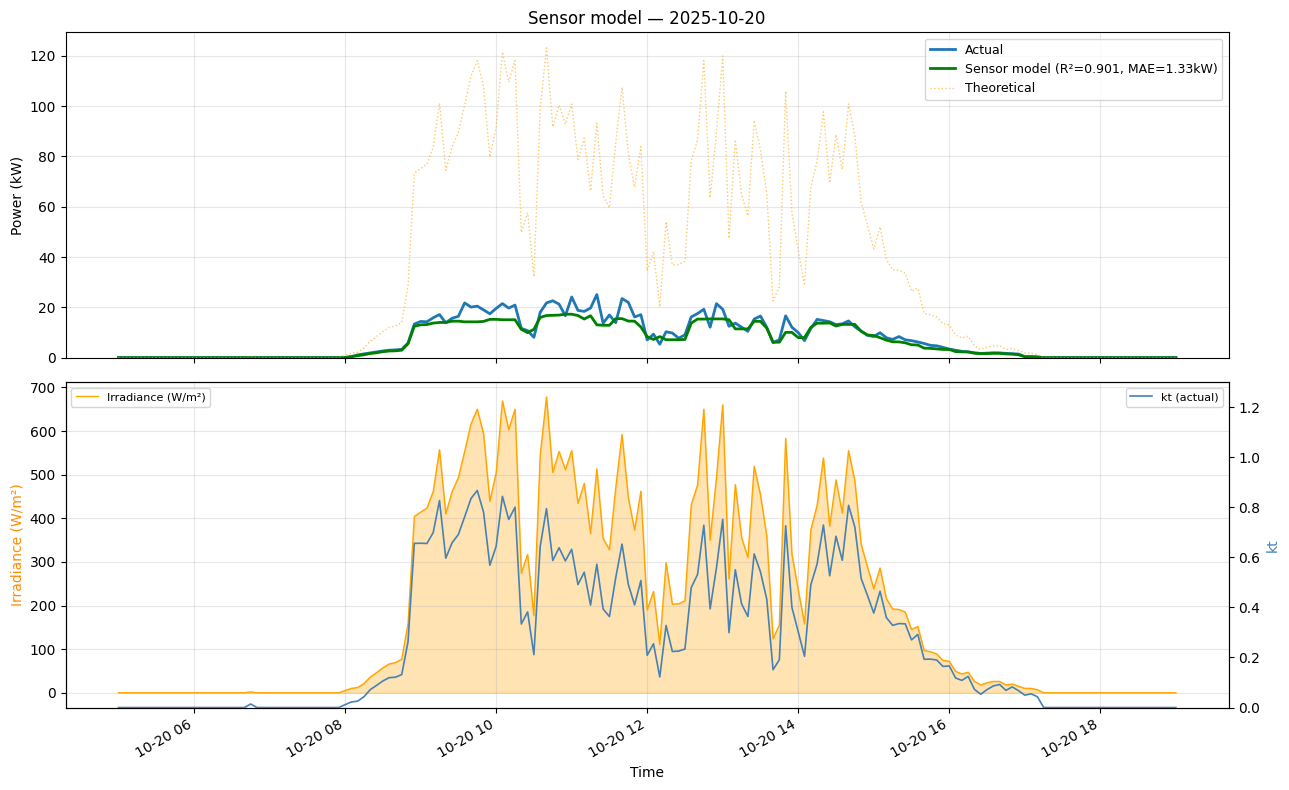

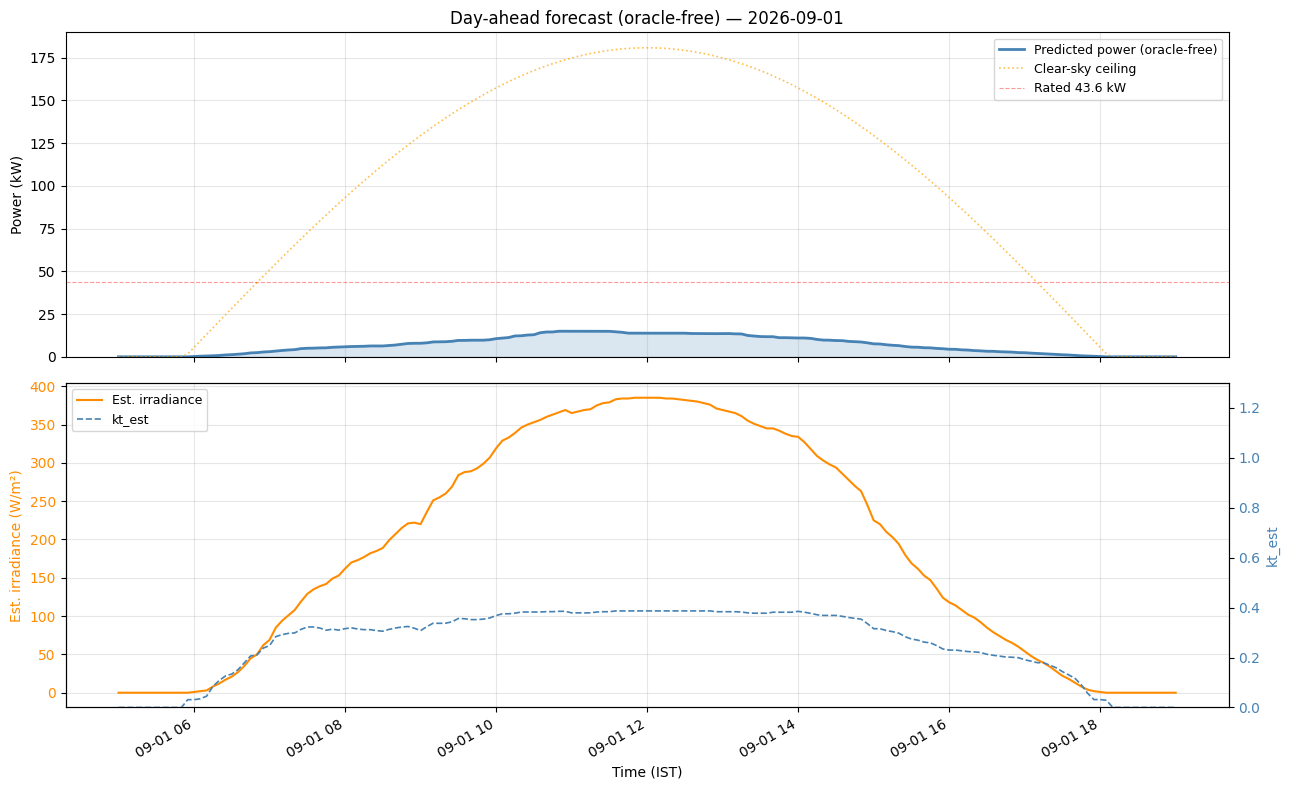

Peak power  : 15.03 kW
Total energy: 95.94 kWh


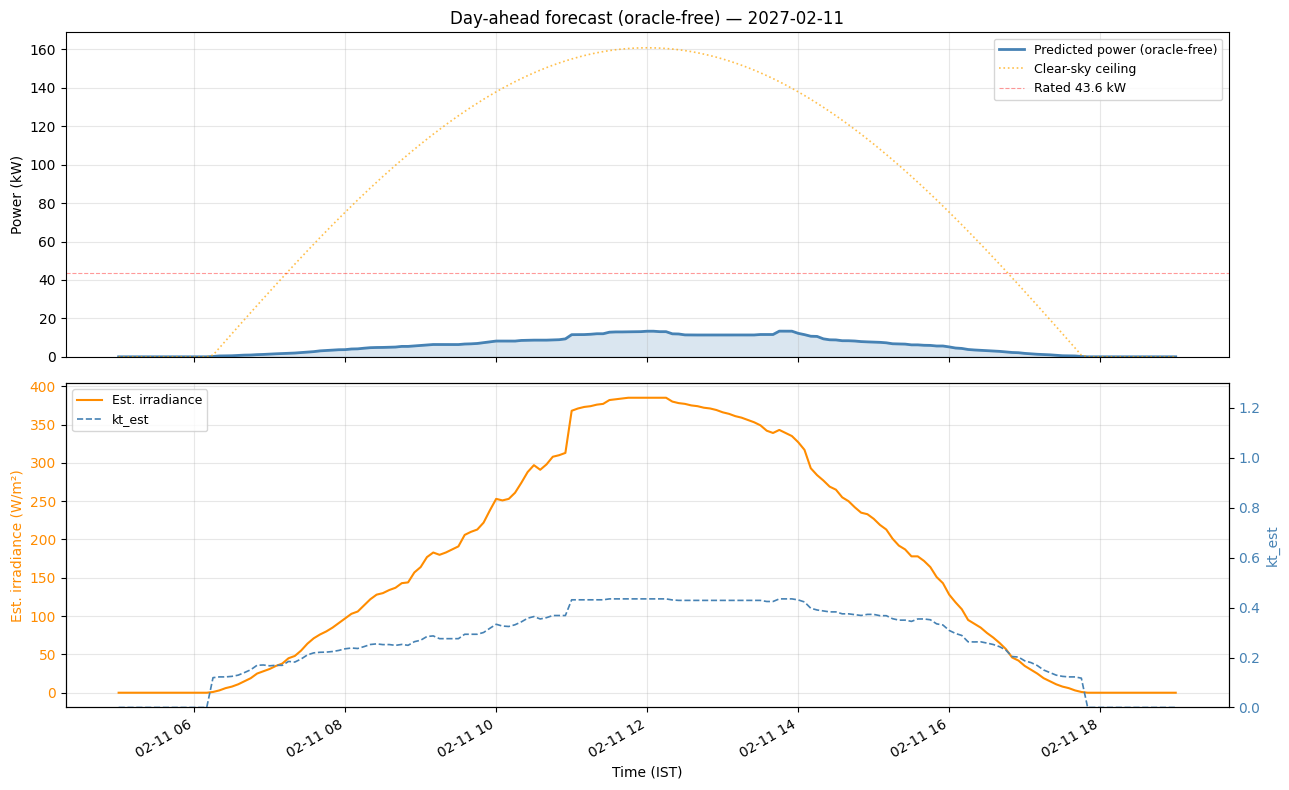

Peak power  : 13.36 kW
Total energy: 79.47 kWh
Saved:
  sensor_model_v6.pkl      — R²=0.94, use with real-time SEMS irradiance
  oracle_model_v6.pkl      — R²=0.51, use for day-ahead weather forecast
  kt_model_monsoon_v6.pkl  — kt estimator Jun-Sep
  kt_model_dry_v6.pkl      — kt estimator Oct-May


In [1]:
%run solar_v6.ipynb

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ── colour palette (consistent across all plots) ──────────────────────────
C_SENSOR  = "#2196F3"   # blue  — sensor model
C_ORACLE  = "#FF7043"   # orange — oracle model
C_ACTUAL  = "#212121"   # near-black — actual power
C_CSIRR   = "#FFA726"   # amber — clear-sky
C_KT      = "#66BB6A"   # green — kt
C_GRID    = 0.25        # grid alpha

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": C_GRID,
    "figure.dpi": 110,
})

# ── sanity check: required variables from v6 notebook ─────────────────────
required = ["test","te_e","sensor_model","oracle_model",
            "kt_model_monsoon","kt_model_dry",
            "FEATURES_SENSOR","FEATURES_ORACLE","WEATHER_FEATS",
            "RATED_KW","AREA_EFF","LATITUDE","train"]
missing = [v for v in required if v not in dir()]
if missing:
    print(f"⚠  Run the v6 notebook first. Missing: {missing}")
else:
    test["date"]  = test["time"].dt.date
    test["month"] = test["time"].dt.month
    te_e["date"]  = te_e["time"].dt.date
    te_e["month"] = te_e["time"].dt.month
    dm_s = test["cs_irr"] > 10
    dm_o = te_e["cs_irr"] > 10
    test["residual_s"] = test["power"] - test["pred_sensor"]
    te_e["residual_o"] = te_e["power"] - te_e["pred_oracle"]
    print("All variables found — ready to plot.")


⚠  Run the v6 notebook first. Missing: ['test', 'te_e', 'sensor_model', 'oracle_model', 'kt_model_monsoon', 'kt_model_dry', 'FEATURES_SENSOR', 'FEATURES_ORACLE', 'WEATHER_FEATS', 'RATED_KW', 'AREA_EFF', 'LATITUDE', 'train']


## 1. Overall metrics — sensor vs oracle

In [3]:
# Day masks
dm_s = test["irradiance"] > 50
dm_o = te_e["irradiance"] > 50

metrics_s = {
    "R² (all)":  r2_score(test["power"], test["pred_sensor"]),
    "R² (day)":  r2_score(test["power"][dm_s], test["pred_sensor"][dm_s]),
    "MAE (day)": mean_absolute_error(test["power"][dm_s], test["pred_sensor"][dm_s]),
    "RMSE (day)":np.sqrt(mean_squared_error(test["power"][dm_s], test["pred_sensor"][dm_s])),
}

metrics_o = {
    "R² (all)":  r2_score(te_e["power"], te_e["pred_oracle"]),
    "R² (day)":  r2_score(te_e["power"][dm_o], te_e["pred_oracle"][dm_o]),
    "MAE (day)": mean_absolute_error(te_e["power"][dm_o], te_e["pred_oracle"][dm_o]),
    "RMSE (day)":np.sqrt(mean_squared_error(te_e["power"][dm_o], te_e["pred_oracle"][dm_o])),
}

NameError: name 'te_e' is not defined

## 2. Monthly R² — sensor vs oracle (daytime rows only)

In [ ]:
# Build monthly R² for both models
monthly_r2 = {}
for mn, grp in test[dm_s].groupby(test[dm_s]["time"].dt.strftime("%Y-%m")):
    monthly_r2[mn] = {"sensor": r2_score(grp["power"], grp["pred_sensor"])}
for mn, grp in te_e[dm_o].groupby(te_e[dm_o]["time"].dt.strftime("%Y-%m")):
    if mn in monthly_r2:
        monthly_r2[mn]["oracle"] = r2_score(grp["power"], grp["pred_oracle"])

mdf = pd.DataFrame(monthly_r2).T.sort_index().dropna()
# Clip oracle R² to [-0.5, 1] for readability — Jan 2025 is -14 (kt cold-start)
mdf["oracle"] = mdf["oracle"].clip(-0.5, 1.0)

fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(len(mdf))
ax.plot(x, mdf["sensor"], "o-", color=C_SENSOR, lw=2, ms=7, label="Sensor")
ax.plot(x, mdf["oracle"], "s--", color=C_ORACLE, lw=2, ms=7, label="Oracle-free")
ax.fill_between(x, mdf["sensor"], mdf["oracle"],
                where=mdf["sensor"]>mdf["oracle"],
                alpha=0.12, color=C_SENSOR, label="Sensor advantage")
ax.axhline(0, color="grey", lw=0.8, ls=":")
ax.axhline(0.9, color=C_SENSOR, lw=0.6, ls=":", alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(mdf.index, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("R² (daytime rows)"); ax.set_ylim(-0.6, 1.05)
ax.set_title("Monthly R² — sensor model vs oracle-free")
ax.legend()
plt.tight_layout(); plt.show()

print("Jan 2025 oracle R² clipped to -0.5 (actual=-14, kt cold-start artefact)")


## 3. Actual vs predicted scatter (daytime)

In [ ]:
np.random.seed(42)
idx_s = np.random.choice(test[dm_s].index, min(4000, dm_s.sum()), replace=False)
idx_o = np.random.choice(te_e[dm_o].index, min(4000, dm_o.sum()), replace=False)
samp_s = test.loc[idx_s]; samp_o = te_e.loc[idx_o]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lim = RATED_KW * 1.05

for ax, samp, pred_col, label, color in [
    (axes[0], samp_s, "pred_sensor", "Sensor model",    C_SENSOR),
    (axes[1], samp_o, "pred_oracle", "Oracle-free model",C_ORACLE),
]:
    ax.scatter(samp["power"], samp[pred_col],
               alpha=0.18, s=5, color=color, rasterized=True)
    ax.plot([0, lim], [0, lim], "k--", lw=1.2, label="Perfect")
    r2  = r2_score(samp["power"], samp[pred_col])
    mae = mean_absolute_error(samp["power"], samp[pred_col])
    ax.text(0.04, 0.93, f"R² = {r2:.3f}\nMAE = {mae:.2f} kW",
            transform=ax.transAxes, fontsize=10, va="top",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Actual power (kW)"); ax.set_ylabel("Predicted power (kW)")
    ax.set_title(label); ax.legend(fontsize=8)

plt.suptitle("Actual vs predicted — daytime test set sample", fontsize=12)
plt.tight_layout(); plt.show()


## 4. Mean residual by hour of day

Shows systematic bias — positive = model underpredicts, negative = overpredicts.

In [ ]:
test["hour_int"] = test["time"].dt.hour
te_e["hour_int"] = te_e["time"].dt.hour

res_s = test[dm_s].groupby("hour_int")["residual_s"].agg(["mean","std"])
res_o = te_e[dm_o].groupby("hour_int")["residual_o"].agg(["mean","std"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, res, label, color in [
    (axes[0], res_s, "Sensor model",    C_SENSOR),
    (axes[1], res_o, "Oracle-free model",C_ORACLE),
]:
    ax.bar(res.index, res["mean"], color=color, alpha=0.8, label="Mean residual")
    ax.fill_between(res.index,
                    res["mean"] - res["std"],
                    res["mean"] + res["std"],
                    alpha=0.2, color=color, label="±1 std")
    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.set_xlabel("Hour of day"); ax.set_ylabel("Residual (actual − predicted) kW")
    ax.set_title(f"{label} — mean residual by hour")
    ax.set_xticks(range(6, 19))
    ax.legend(fontsize=8)

plt.suptitle("Bias analysis — systematic under/overprediction by hour", fontsize=12)
plt.tight_layout(); plt.show()


## 5. Performance by season

In [ ]:
seasons = {
    "Winter\n(Jan–Feb)":    [1, 2],
    "Summer\n(Mar–May)":    [3, 4, 5],
    "Monsoon\n(Jun–Sep)":   [6, 7, 8, 9],
    "Post-Mon\n(Oct–Dec)":  [10, 11, 12],
}

r2_s, r2_o, mae_s, mae_o, labels = [], [], [], [], []
for name, months in seasons.items():
    g_s = test[test["month"].isin(months) & dm_s]
    g_o = te_e[te_e["month"].isin(months) & dm_o]
    r2_s.append(r2_score(g_s["power"], g_s["pred_sensor"]))
    r2_o.append(r2_score(g_o["power"], g_o["pred_oracle"]))
    mae_s.append(mean_absolute_error(g_s["power"], g_s["pred_sensor"]))
    mae_o.append(mean_absolute_error(g_o["power"], g_o["pred_oracle"]))
    labels.append(name)

x = np.arange(len(labels)); w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(x-w/2, r2_s, w, color=C_SENSOR, alpha=0.85, label="Sensor")
axes[0].bar(x+w/2, r2_o, w, color=C_ORACLE, alpha=0.85, label="Oracle-free")
for i,(a,b) in enumerate(zip(r2_s,r2_o)):
    axes[0].text(i-w/2, a+0.005, f"{a:.3f}", ha="center", fontsize=8)
    axes[0].text(i+w/2, b+0.005, f"{b:.3f}", ha="center", fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylabel("R²"); axes[0].set_title("R² by season"); axes[0].legend()
axes[0].set_ylim(0, 1.05)

axes[1].bar(x-w/2, mae_s, w, color=C_SENSOR, alpha=0.85, label="Sensor")
axes[1].bar(x+w/2, mae_o, w, color=C_ORACLE, alpha=0.85, label="Oracle-free")
for i,(a,b) in enumerate(zip(mae_s,mae_o)):
    axes[1].text(i-w/2, a+0.05, f"{a:.2f}", ha="center", fontsize=8)
    axes[1].text(i+w/2, b+0.05, f"{b:.2f}", ha="center", fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, fontsize=9)
axes[1].set_ylabel("MAE (kW)"); axes[1].set_title("MAE by season"); axes[1].legend()

plt.suptitle("Seasonal performance breakdown (daytime rows)", fontsize=12)
plt.tight_layout(); plt.show()


## 6. Feature importance — sensor vs oracle

In [ ]:
fi_s = pd.Series(sensor_model.feature_importances_, index=FEATURES_SENSOR).sort_values()
fi_o = pd.Series(oracle_model.feature_importances_, index=FEATURES_ORACLE).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fi_s.plot(kind="barh", ax=axes[0], color=C_SENSOR, alpha=0.85)
axes[0].set_title("Sensor model — feature importance")
axes[0].set_xlabel("XGBoost gain")

fi_o.plot(kind="barh", ax=axes[1], color=C_ORACLE, alpha=0.85)
axes[1].set_title("Oracle-free model — feature importance")
axes[1].set_xlabel("XGBoost gain")

plt.suptitle("Feature importance (XGBoost gain) — both models", fontsize=12)
plt.tight_layout(); plt.show()


## 7. kt estimation quality — actual vs estimated

Shows how well the dual kt model estimates cloud cover from weather alone.

In [ ]:
dm_kt = te_e["cs_irr"] > 10
kt_actual = te_e.loc[dm_kt, "kt"].values
kt_estim  = te_e.loc[dm_kt, "kt_est"].values
is_mon    = te_e.loc[dm_kt, "is_monsoon"].values.astype(bool)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Scatter — monsoon vs dry
ax = axes[0]
ax.scatter(kt_actual[~is_mon], kt_estim[~is_mon],
           alpha=0.08, s=4, color=C_SENSOR, label="Dry season", rasterized=True)
ax.scatter(kt_actual[is_mon], kt_estim[is_mon],
           alpha=0.12, s=4, color=C_ORACLE, label="Monsoon", rasterized=True)
ax.plot([0,1.2],[0,1.2],"k--",lw=1)
ax.set_xlabel("Actual kt"); ax.set_ylabel("Estimated kt")
ax.set_title("Actual vs estimated kt")
r2_mon = r2_score(kt_actual[is_mon],  kt_estim[is_mon])
r2_dry = r2_score(kt_actual[~is_mon], kt_estim[~is_mon])
ax.text(0.04, 0.93, f"Monsoon R²={r2_mon:.3f}\nDry R²={r2_dry:.3f}",
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
ax.legend(fontsize=8, markerscale=4)

# kt distribution by model type
ax2 = axes[1]
ax2.hist(kt_actual, bins=40, alpha=0.5, color=C_ACTUAL, label="Actual kt", density=True)
ax2.hist(kt_estim,  bins=40, alpha=0.5, color=C_SENSOR, label="Estimated kt", density=True)
ax2.set_xlabel("kt value"); ax2.set_ylabel("Density")
ax2.set_title("kt distribution — actual vs estimated")
ax2.legend(fontsize=9)

# Mean kt by hour
te_e["hour_int"] = te_e["time"].dt.hour
kt_by_hour = te_e[dm_kt].groupby("hour_int").agg(
    kt_actual=("kt","mean"), kt_est=("kt_est","mean"))
ax3 = axes[2]
ax3.plot(kt_by_hour.index, kt_by_hour["kt_actual"], "o-", color=C_ACTUAL, lw=2, label="Actual kt")
ax3.plot(kt_by_hour.index, kt_by_hour["kt_est"],    "s--", color=C_SENSOR, lw=2, label="Estimated kt")
ax3.set_xlabel("Hour of day"); ax3.set_ylabel("Mean kt")
ax3.set_title("Mean kt by hour — actual vs estimated")
ax3.legend(fontsize=9)

plt.suptitle("kt estimation quality (clearness index)", fontsize=12)
plt.tight_layout(); plt.show()

print(f"Overall test kt R² — monsoon model: {r2_mon:.4f}")
print(f"Overall test kt R² — dry model:     {r2_dry:.4f}")


## 8. Day-level plots — sensor model (4 seasons)

In [ ]:
def plot_day_sensor(date_str, smooth=3):
    d   = pd.to_datetime(date_str).date()
    sel = test[test["date"] == d].copy()
    if sel.empty: print(f"No data for {date_str}"); return
    raw    = sel["pred_sensor"].values
    smooth_pred = pd.Series(raw).rolling(smooth, center=True, min_periods=1).median().values
    smooth_pred = np.minimum(np.clip(smooth_pred, 0, RATED_KW), sel["theo_power"].values)
    r2  = r2_score(sel["power"], smooth_pred)
    mae = mean_absolute_error(sel["power"], smooth_pred)

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    ax = axes[0]
    ax.plot(sel["time"], sel["power"],     lw=2,   color=C_ACTUAL,  label="Actual")
    ax.plot(sel["time"], smooth_pred,      lw=2,   color=C_SENSOR, ls="--",
            label=f"Sensor (R²={r2:.3f}, MAE={mae:.2f}kW)")
    ax.plot(sel["time"], sel["theo_power"],lw=1,   color=C_CSIRR,  ls=":", alpha=0.7,
            label="Theoretical ceiling")
    ax.set_ylabel("Power (kW)"); ax.set_ylim(0)
    ax.legend(fontsize=8); ax.set_title(f"Sensor model — {date_str}")

    ax2 = axes[1]
    ax2.fill_between(sel["time"], sel["irradiance"], alpha=0.25, color=C_CSIRR)
    ax2.plot(sel["time"], sel["irradiance"], lw=1, color=C_CSIRR, label="Irradiance (W/m²)")
    ax2r = ax2.twinx()
    ax2r.plot(sel["time"], sel["kt"], lw=1.3, color=C_KT, label="kt (actual)")
    ax2r.set_ylim(0, 1.3); ax2r.set_ylabel("kt", color=C_KT)
    ax2.set_ylabel("Irradiance (W/m²)", color=C_CSIRR)
    ax2.set_xlabel("Time")
    ax2.legend(loc="upper left", fontsize=8); ax2r.legend(loc="upper right", fontsize=8)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
    plt.tight_layout(); plt.show()

for date in ["2025-01-01", "2025-04-25", "2025-08-29", "2025-11-15"]:
    plot_day_sensor(date)


## 9. Day-level plots — oracle-free model (4 seasons)

In [ ]:
def plot_day_oracle(date_str, smooth=3):
    d   = pd.to_datetime(date_str).date()
    sel = te_e[te_e["date"] == d].copy()
    if sel.empty: print(f"No data for {date_str}"); return
    raw    = sel["pred_oracle"].values
    smooth_pred = pd.Series(raw).rolling(smooth, center=True, min_periods=1).median().values
    smooth_pred = np.minimum(np.clip(smooth_pred, 0, RATED_KW), sel["theo_power_est"].values)
    r2  = r2_score(sel["power"], smooth_pred)
    mae = mean_absolute_error(sel["power"], smooth_pred)

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    ax = axes[0]
    ax.plot(sel["time"], sel["power"],         lw=2, color=C_ACTUAL, label="Actual")
    ax.plot(sel["time"], smooth_pred,          lw=2, color=C_ORACLE, ls="--",
            label=f"Oracle-free (R²={r2:.3f}, MAE={mae:.2f}kW)")
    ax.plot(sel["time"], sel["cs_power"],      lw=1, color=C_CSIRR, ls=":", alpha=0.7,
            label="Clear-sky ceiling")
    ax.set_ylabel("Power (kW)"); ax.set_ylim(0)
    ax.legend(fontsize=8); ax.set_title(f"Oracle-free model — {date_str}")

    ax2 = axes[1]
    ax2.fill_between(sel["time"], sel["irr_est"], alpha=0.25, color=C_ORACLE)
    ax2.plot(sel["time"], sel["irr_est"],  lw=1, color=C_ORACLE, label="Est. irradiance (W/m²)")
    ax2.plot(sel["time"], sel["irradiance"], lw=1, color=C_ACTUAL, ls="--", alpha=0.6,
             label="Actual irradiance")
    ax2r = ax2.twinx()
    ax2r.plot(sel["time"], sel["kt_est"], lw=1.3, color=C_KT, ls="--", label="kt_est")
    ax2r.plot(sel["time"], sel["kt"],     lw=1.0, color=C_KT, alpha=0.5, label="kt_actual")
    ax2r.set_ylim(0, 1.3); ax2r.set_ylabel("kt", color=C_KT)
    ax2.set_ylabel("Irradiance (W/m²)"); ax2.set_xlabel("Time")
    ax2.legend(loc="upper left", fontsize=8); ax2r.legend(loc="upper right", fontsize=8)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
    plt.tight_layout(); plt.show()

for date in ["2025-02-26", "2026-03-07", "2025-06-25", "2025-10-02"]:
    plot_day_oracle(date)


## 10. Power output distribution — actual vs predicted

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bins = np.linspace(0, RATED_KW, 40)

for ax, pred_col, ds, dm, color, label in [
    (axes[0], "pred_sensor", test, dm_s, C_SENSOR, "Sensor model"),
    (axes[1], "pred_oracle", te_e, dm_o, C_ORACLE, "Oracle-free model"),
]:
    ax.hist(ds.loc[dm, "power"],     bins=bins, alpha=0.5, color=C_ACTUAL,
            label="Actual", density=True)
    ax.hist(ds.loc[dm, pred_col],    bins=bins, alpha=0.5, color=color,
            label=label, density=True)
    ax.set_xlabel("Power (kW)"); ax.set_ylabel("Density")
    ax.set_title(f"Power distribution — {label}")
    ax.legend(fontsize=9)

plt.suptitle("Power output distribution (daytime, test set)", fontsize=12)
plt.tight_layout(); plt.show()


## 11. Daily energy output — rolling 30-day mean

In [ ]:
# Daily totals (kWh = sum of 5-min kW × 5/60)
def daily_energy(ds, pred_col):
    ds = ds.copy(); ds["date"] = ds["time"].dt.date
    daily = ds.groupby("date").apply(
        lambda g: pd.Series({
            "actual_kwh":    g["power"].sum() * 5/60,
            "predicted_kwh": g[pred_col].sum() * 5/60,
        })
    ).reset_index()
    daily["date"] = pd.to_datetime(daily["date"])
    return daily

daily_s = daily_energy(test, "pred_sensor")
daily_o = daily_energy(te_e, "pred_oracle")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

for ax, daily, pred_label, color in [
    (axes[0], daily_s, "Sensor model",    C_SENSOR),
    (axes[1], daily_o, "Oracle-free model",C_ORACLE),
]:
    win = 30
    ax.plot(daily["date"], daily["actual_kwh"].rolling(win, center=True).mean(),
            lw=2, color=C_ACTUAL, label="Actual (30-day mean)")
    ax.plot(daily["date"], daily["predicted_kwh"].rolling(win, center=True).mean(),
            lw=2, color=color, ls="--", label=f"{pred_label} (30-day mean)")
    ax.fill_between(daily["date"],
                    daily["actual_kwh"].rolling(win, center=True).mean(),
                    daily["predicted_kwh"].rolling(win, center=True).mean(),
                    alpha=0.15, color=color)
    mae_d = mean_absolute_error(daily["actual_kwh"], daily["predicted_kwh"])
    ax.set_ylabel("Daily energy (kWh)"); ax.legend(fontsize=9)
    ax.set_title(f"{pred_label} — 30-day rolling mean daily energy  |  daily MAE={mae_d:.1f} kWh")
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.suptitle("Daily energy output — actual vs predicted", fontsize=12)
plt.tight_layout(); plt.show()


## 12. Residual heatmap — hour × month

In [ ]:
test["hour_int"] = test["time"].dt.hour
te_e["hour_int"] = te_e["time"].dt.hour

pivot_s = test[dm_s].pivot_table(
    values="residual_s", index="hour_int", columns="month", aggfunc="mean")
pivot_o = te_e[dm_o].pivot_table(
    values="residual_o", index="hour_int", columns="month", aggfunc="mean")

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, pivot, title in [
    (axes[0], pivot_s, "Sensor model residual"),
    (axes[1], pivot_o, "Oracle-free residual"),
]:
    vmax = max(abs(pivot.values[~np.isnan(pivot.values)]).max(), 0.1)
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r",
                   vmin=-vmax, vmax=vmax, origin="lower")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([month_labels[m-1] for m in pivot.columns], fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_xlabel("Month"); ax.set_ylabel("Hour of day")
    ax.set_title(f"{title}\n(blue=underpredict, red=overpredict)")
    plt.colorbar(im, ax=ax, label="Mean residual (kW)", shrink=0.8)

plt.suptitle("Residual heatmap — mean (actual − predicted) by hour & month", fontsize=12)
plt.tight_layout(); plt.show()


## 13. Sensor vs oracle — same day comparison

In [ ]:
def plot_day_comparison(date_str):
    d = pd.to_datetime(date_str).date()
    s  = test[test["date"] == d].copy()
    o  = te_e[te_e["date"] == d].copy()
    if s.empty or o.empty:
        print(f"No data for {date_str}"); return

    sp = np.minimum(pd.Series(s["pred_sensor"].values)
                    .rolling(3, center=True, min_periods=1).median().values,
                    s["theo_power"].values).clip(0, RATED_KW)
    op = np.minimum(pd.Series(o["pred_oracle"].values)
                    .rolling(3, center=True, min_periods=1).median().values,
                    o["theo_power_est"].values).clip(0, RATED_KW)

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(s["time"], s["power"], lw=2.5, color=C_ACTUAL, label="Actual", zorder=5)
    ax.plot(s["time"], sp, lw=2, color=C_SENSOR, ls="--",
            label=f"Sensor  R²={r2_score(s['power'], sp):.3f}  MAE={mean_absolute_error(s['power'], sp):.2f}kW")
    ax.plot(o["time"], op, lw=2, color=C_ORACLE, ls="-.",
            label=f"Oracle  R²={r2_score(o['power'], op):.3f}  MAE={mean_absolute_error(o['power'], op):.2f}kW")
    ax.plot(s["time"], s["theo_power"], lw=1, color=C_CSIRR, ls=":", alpha=0.6,
            label="Theoretical ceiling")
    ax.set_ylabel("Power (kW)"); ax.set_ylim(0)
    ax.legend(fontsize=9); ax.set_xlabel("Time")
    ax.set_title(f"Sensor vs oracle-free — {date_str}")
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
    plt.tight_layout(); plt.show()

for date in ["2025-03-15", "2025-06-11", "2025-10-20", "2026-02-14"]:
    plot_day_comparison(date)
